# Strategy Comparison Analysis

This notebook provides a comprehensive analysis comparing evaluation results across:

1. **K Values**: Comparing k=3, k=5, and k=10 for each strategy
2. **Overlap Sizes**: Comparing medium chunks vs small overlaps for each strategy
3. **Chunking Methods**: Comparing small chunks vs medium chunks for each strategy

The goal is to identify the **best combination** of parameters for optimal retrieval performance.


## 1. Setup and Imports


In [31]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
import os
warnings.filterwarnings('ignore')

# Configure plotting
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

# Set base directory - handle both running from root and from evaluation directory
current_dir = Path.cwd()
if current_dir.name == 'evaluation':
    # Running from evaluation directory
    EVAL_DIR = current_dir
    BASE_DIR = current_dir.parent
else:
    # Running from project root
    BASE_DIR = current_dir
    EVAL_DIR = BASE_DIR / "evaluation"

RESULTS_DIR = EVAL_DIR / "strategy_comparison_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Imports loaded successfully!")
print(f"📁 Current directory: {current_dir}")
print(f"📁 Evaluation directory: {EVAL_DIR}")
print(f"📁 Results will be saved to: {RESULTS_DIR}")


✅ Imports loaded successfully!
📁 Current directory: c:\Users\LENOVO\OneDrive - Technion\Desktop\DataSience\semester8\lab2\evaluation
📁 Evaluation directory: c:\Users\LENOVO\OneDrive - Technion\Desktop\DataSience\semester8\lab2\evaluation
📁 Results will be saved to: c:\Users\LENOVO\OneDrive - Technion\Desktop\DataSience\semester8\lab2\evaluation\strategy_comparison_results


## 2. Data Loading Functions


In [32]:
def load_evaluation_results(file_path):
    """Load evaluation results CSV file."""
    try:
        df = pd.read_csv(file_path)
        return df
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

def aggregate_strategy_metrics(df):
    """Aggregate metrics by strategy."""
    if df is None or df.empty:
        return None
    
    metrics = [
        'avg_score', 'max_score', 'min_score', 'precision', 'recall', 'accuracy',
        'namespace_correct', 'num_results', 'unique_docs'
    ]
    
    agg_dict = {}
    for metric in metrics:
        if metric in df.columns:
            agg_dict[metric] = ['mean', 'std', 'min', 'max']
    
    if not agg_dict:
        return None
    
    grouped = df.groupby('strategy').agg(agg_dict)
    return grouped

print("✅ Data loading functions defined!")


✅ Data loading functions defined!


## 3. Load All Evaluation Data


In [33]:
# Load k-value results
k3_results = load_evaluation_results(EVAL_DIR / "results_k3" / "evaluation_results.csv")
k5_results = load_evaluation_results(EVAL_DIR / "results_k5" / "evaluation_results.csv")
k10_results = load_evaluation_results(EVAL_DIR / "results_k10" / "evaluation_results.csv")

# Load chunk config results
small_chunks_results = load_evaluation_results(
    EVAL_DIR / "chunk_config_evaluations" / "small_chunks" / "evaluation_results" / "evaluation_results.csv"
)
medium_chunks_results = load_evaluation_results(
    EVAL_DIR / "chunk_config_evaluations" / "medium_chunks" / "evaluation_results" / "evaluation_results.csv"
)
small_overlap_results = load_evaluation_results(
    EVAL_DIR / "chunk_config_evaluations" / "small_overlap" / "evaluation_results" / "evaluation_results.csv"
)

# Add metadata columns
if k3_results is not None:
    k3_results['k_value'] = 3
if k5_results is not None:
    k5_results['k_value'] = 5
if k10_results is not None:
    k10_results['k_value'] = 10

if small_chunks_results is not None:
    small_chunks_results['chunk_size'] = 'small'
if medium_chunks_results is not None:
    medium_chunks_results['chunk_size'] = 'medium'
if small_overlap_results is not None:
    small_overlap_results['overlap_size'] = 'small'
    # Assume medium chunks for small_overlap (based on directory structure)
    small_overlap_results['chunk_size'] = 'medium'

print("✅ Data loaded successfully!")
print(f"\nData shapes:")
print(f"  k3_results: {k3_results.shape if k3_results is not None else 'None'}")
print(f"  k5_results: {k5_results.shape if k5_results is not None else 'None'}")
print(f"  k10_results: {k10_results.shape if k10_results is not None else 'None'}")
print(f"  small_chunks_results: {small_chunks_results.shape if small_chunks_results is not None else 'None'}")
print(f"  medium_chunks_results: {medium_chunks_results.shape if medium_chunks_results is not None else 'None'}")
print(f"  small_overlap_results: {small_overlap_results.shape if small_overlap_results is not None else 'None'}")


✅ Data loaded successfully!

Data shapes:
  k3_results: (20, 20)
  k5_results: (20, 20)
  k10_results: (20, 20)
  small_chunks_results: (60, 20)
  medium_chunks_results: (60, 20)
  small_overlap_results: (60, 21)


## 4. Analysis 1: Strategy Comparison Across K Values (3, 5, 10)


In [34]:
# Combine k-value results
k_comparison_data = []

for k_df, k_val in [(k3_results, 3), (k5_results, 5), (k10_results, 10)]:
    if k_df is not None:
        for strategy in k_df['strategy'].unique():
            strategy_df = k_df[k_df['strategy'] == strategy]
            k_comparison_data.append({
                'k_value': k_val,
                'strategy': strategy,
                'avg_score_mean': strategy_df['avg_score'].mean(),
                'avg_score_std': strategy_df['avg_score'].std(),
                'max_score_mean': strategy_df['max_score'].mean(),
                'precision_mean': strategy_df['precision'].mean(),
                'recall_mean': strategy_df['recall'].mean(),
                'accuracy_mean': strategy_df['accuracy'].mean(),
                'namespace_correct_rate': strategy_df['namespace_correct'].mean(),
                'num_queries': len(strategy_df)
            })

k_comparison_df = pd.DataFrame(k_comparison_data)
print("✅ K-value comparison data prepared!")
print(f"\n{k_comparison_df.head(10)}")


✅ K-value comparison data prepared!

   k_value  strategy  avg_score_mean  avg_score_std  max_score_mean  \
0        3  adaptive        0.525941       0.124690        0.544321   
1        5  adaptive        0.516635       0.128450        0.544321   
2       10  adaptive        0.502985       0.134729        0.544321   

   precision_mean  recall_mean  accuracy_mean  namespace_correct_rate  \
0            0.10     0.100000           0.10                     1.0   
1            0.08     0.133333           0.08                     1.0   
2            0.06     0.200000           0.06                     1.0   

   num_queries  
0           20  
1           20  
2           20  


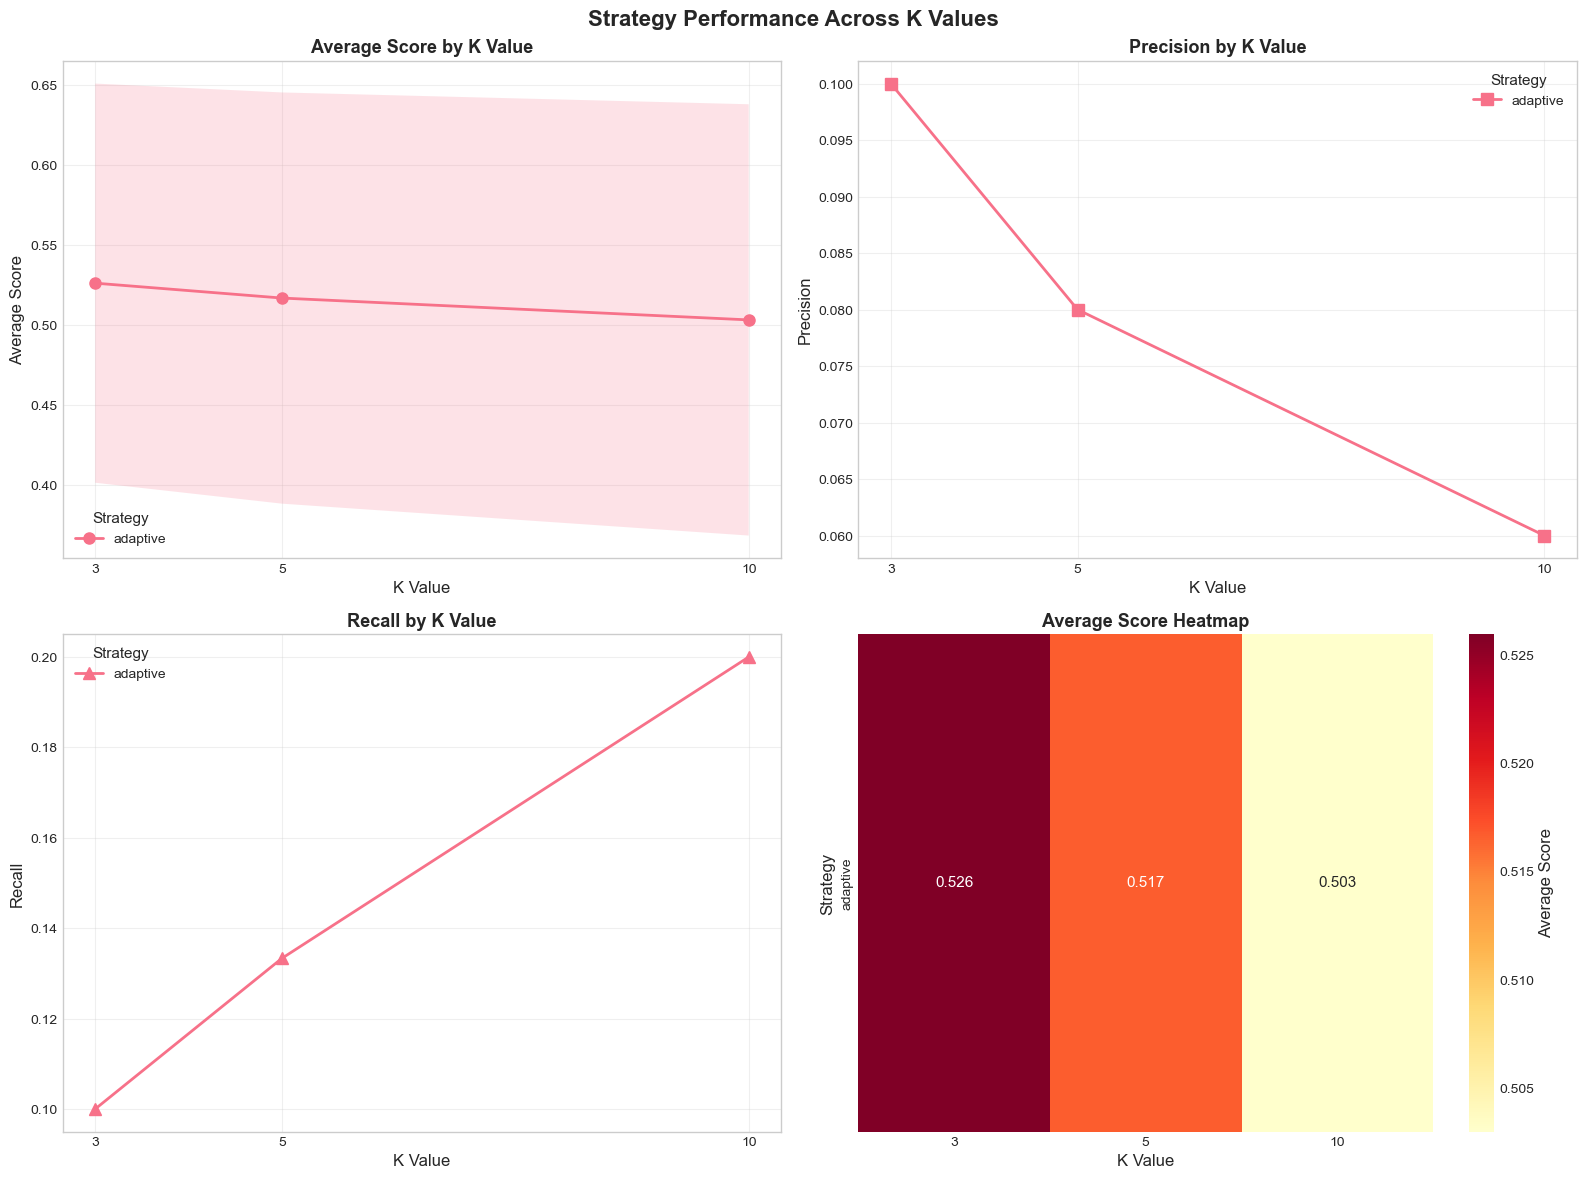

✅ K-value comparison visualization saved!


In [35]:
# Visualization 1: Average Score by Strategy and K Value
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Strategy Performance Across K Values', fontsize=16, fontweight='bold')

# Plot 1: Average Score
ax1 = axes[0, 0]
for strategy in k_comparison_df['strategy'].unique():
    strategy_data = k_comparison_df[k_comparison_df['strategy'] == strategy]
    ax1.plot(strategy_data['k_value'], strategy_data['avg_score_mean'], 
             marker='o', linewidth=2, markersize=8, label=strategy)
    ax1.fill_between(strategy_data['k_value'], 
                     strategy_data['avg_score_mean'] - strategy_data['avg_score_std'],
                     strategy_data['avg_score_mean'] + strategy_data['avg_score_std'],
                     alpha=0.2)
ax1.set_xlabel('K Value', fontsize=12)
ax1.set_ylabel('Average Score', fontsize=12)
ax1.set_title('Average Score by K Value', fontsize=13, fontweight='bold')
ax1.legend(title='Strategy', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xticks([3, 5, 10])

# Plot 2: Precision
ax2 = axes[0, 1]
for strategy in k_comparison_df['strategy'].unique():
    strategy_data = k_comparison_df[k_comparison_df['strategy'] == strategy]
    ax2.plot(strategy_data['k_value'], strategy_data['precision_mean'], 
             marker='s', linewidth=2, markersize=8, label=strategy)
ax2.set_xlabel('K Value', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision by K Value', fontsize=13, fontweight='bold')
ax2.legend(title='Strategy', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xticks([3, 5, 10])

# Plot 3: Recall
ax3 = axes[1, 0]
for strategy in k_comparison_df['strategy'].unique():
    strategy_data = k_comparison_df[k_comparison_df['strategy'] == strategy]
    ax3.plot(strategy_data['k_value'], strategy_data['recall_mean'], 
             marker='^', linewidth=2, markersize=8, label=strategy)
ax3.set_xlabel('K Value', fontsize=12)
ax3.set_ylabel('Recall', fontsize=12)
ax3.set_title('Recall by K Value', fontsize=13, fontweight='bold')
ax3.legend(title='Strategy', fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_xticks([3, 5, 10])

# Plot 4: Heatmap of Average Scores
ax4 = axes[1, 1]
heatmap_data = k_comparison_df.pivot(index='strategy', columns='k_value', values='avg_score_mean')
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd', cbar_kws={'label': 'Average Score'}, ax=ax4)
ax4.set_title('Average Score Heatmap', fontsize=13, fontweight='bold')
ax4.set_xlabel('K Value', fontsize=12)
ax4.set_ylabel('Strategy', fontsize=12)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'k_value_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ K-value comparison visualization saved!")


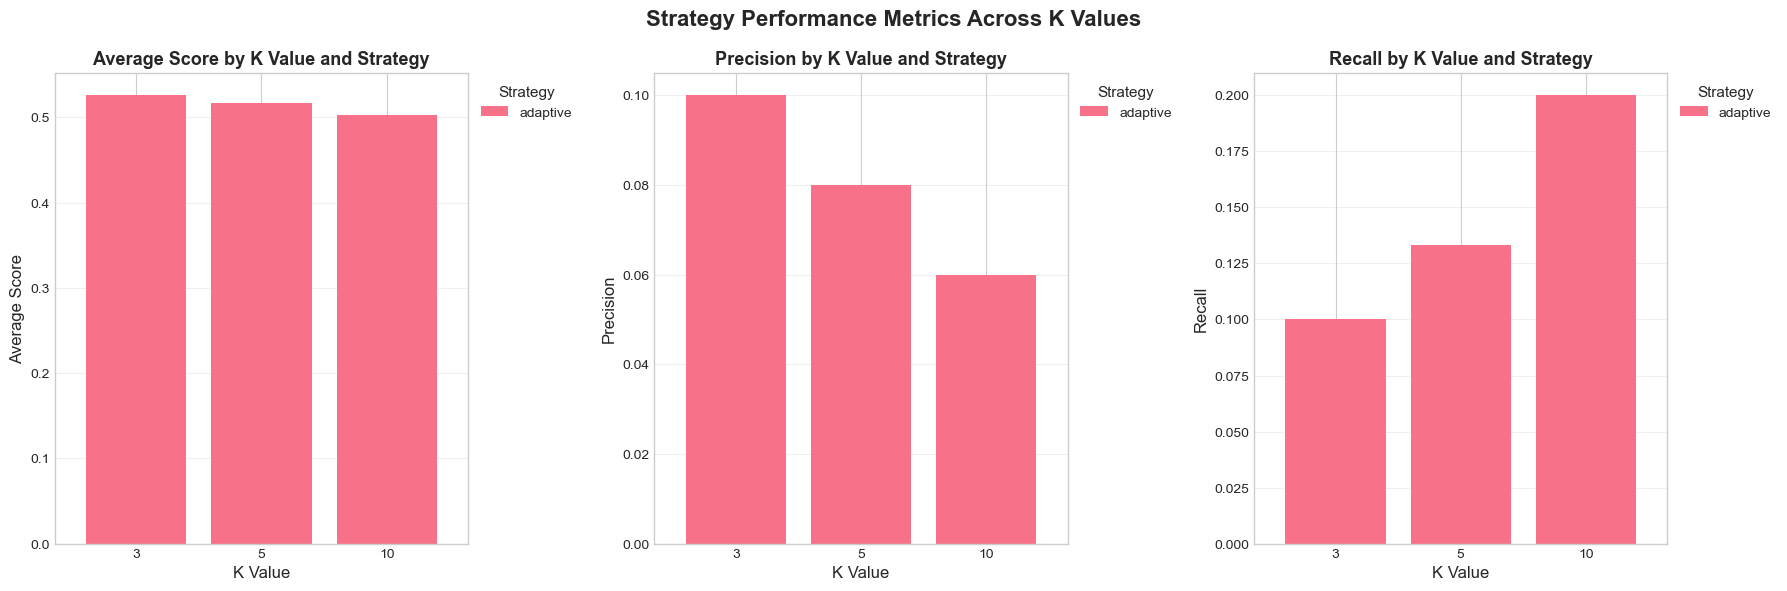

✅ K-value bar chart comparison saved!


In [36]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Strategy Performance Metrics Across K Values', fontsize=16, fontweight='bold')

metrics = ['avg_score_mean', 'precision_mean', 'recall_mean']
metric_labels = ['Average Score', 'Precision', 'Recall']

for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax = axes[idx]
    pivot_data = k_comparison_df.pivot(index='k_value', columns='strategy', values=metric)
    pivot_data.plot(kind='bar', ax=ax, width=0.8)
    ax.set_xlabel('K Value', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.set_title(f'{label} by K Value and Strategy', fontsize=13, fontweight='bold')
    ax.legend(title='Strategy', fontsize=10, loc='upper left', bbox_to_anchor=(1.0, 1.0))
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'k_value_bar_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ K-value bar chart comparison saved!")


## 5. Analysis 2: Strategy Comparison Across Overlap Sizes (Medium Chunks vs Small Overlap)


In [37]:
# Prepare overlap comparison data
# Medium chunks (default overlap) vs Small overlap
overlap_comparison_data = []

# Medium chunks (assuming this has default/medium overlap)
if medium_chunks_results is not None:
    for strategy in medium_chunks_results['strategy'].unique():
        strategy_df = medium_chunks_results[medium_chunks_results['strategy'] == strategy]
        overlap_comparison_data.append({
            'overlap_config': 'medium_chunks',
            'strategy': strategy,
            'avg_score_mean': strategy_df['avg_score'].mean(),
            'avg_score_std': strategy_df['avg_score'].std(),
            'max_score_mean': strategy_df['max_score'].mean(),
            'precision_mean': strategy_df['precision'].mean(),
            'recall_mean': strategy_df['recall'].mean(),
            'accuracy_mean': strategy_df['accuracy'].mean(),
            'namespace_correct_rate': strategy_df['namespace_correct'].mean(),
            'num_queries': len(strategy_df)
        })

# Small overlap (with medium chunks)
if small_overlap_results is not None:
    for strategy in small_overlap_results['strategy'].unique():
        strategy_df = small_overlap_results[small_overlap_results['strategy'] == strategy]
        overlap_comparison_data.append({
            'overlap_config': 'small_overlap',
            'strategy': strategy,
            'avg_score_mean': strategy_df['avg_score'].mean(),
            'avg_score_std': strategy_df['avg_score'].std(),
            'max_score_mean': strategy_df['max_score'].mean(),
            'precision_mean': strategy_df['precision'].mean(),
            'recall_mean': strategy_df['recall'].mean(),
            'accuracy_mean': strategy_df['accuracy'].mean(),
            'namespace_correct_rate': strategy_df['namespace_correct'].mean(),
            'num_queries': len(strategy_df)
        })

overlap_comparison_df = pd.DataFrame(overlap_comparison_data)
print("✅ Overlap comparison data prepared!")
print(f"\n{overlap_comparison_df}")


✅ Overlap comparison data prepared!

  overlap_config  strategy  avg_score_mean  avg_score_std  max_score_mean  \
0  medium_chunks  baseline        0.186470       0.113131        0.242872   
1  medium_chunks  sentence        0.379217       0.115480        0.427168   
2  medium_chunks  adaptive        0.515640       0.130678        0.542172   
3  small_overlap  baseline        0.186470       0.113131        0.242872   
4  small_overlap  sentence        0.379217       0.115480        0.427168   
5  small_overlap  adaptive        0.515640       0.130678        0.542172   

   precision_mean  recall_mean  accuracy_mean  namespace_correct_rate  \
0            0.00          0.0           0.00                     0.9   
1            0.06          0.1           0.06                     1.0   
2            0.06          0.1           0.06                     1.0   
3            0.00          0.0           0.00                     0.9   
4            0.06          0.1           0.06             

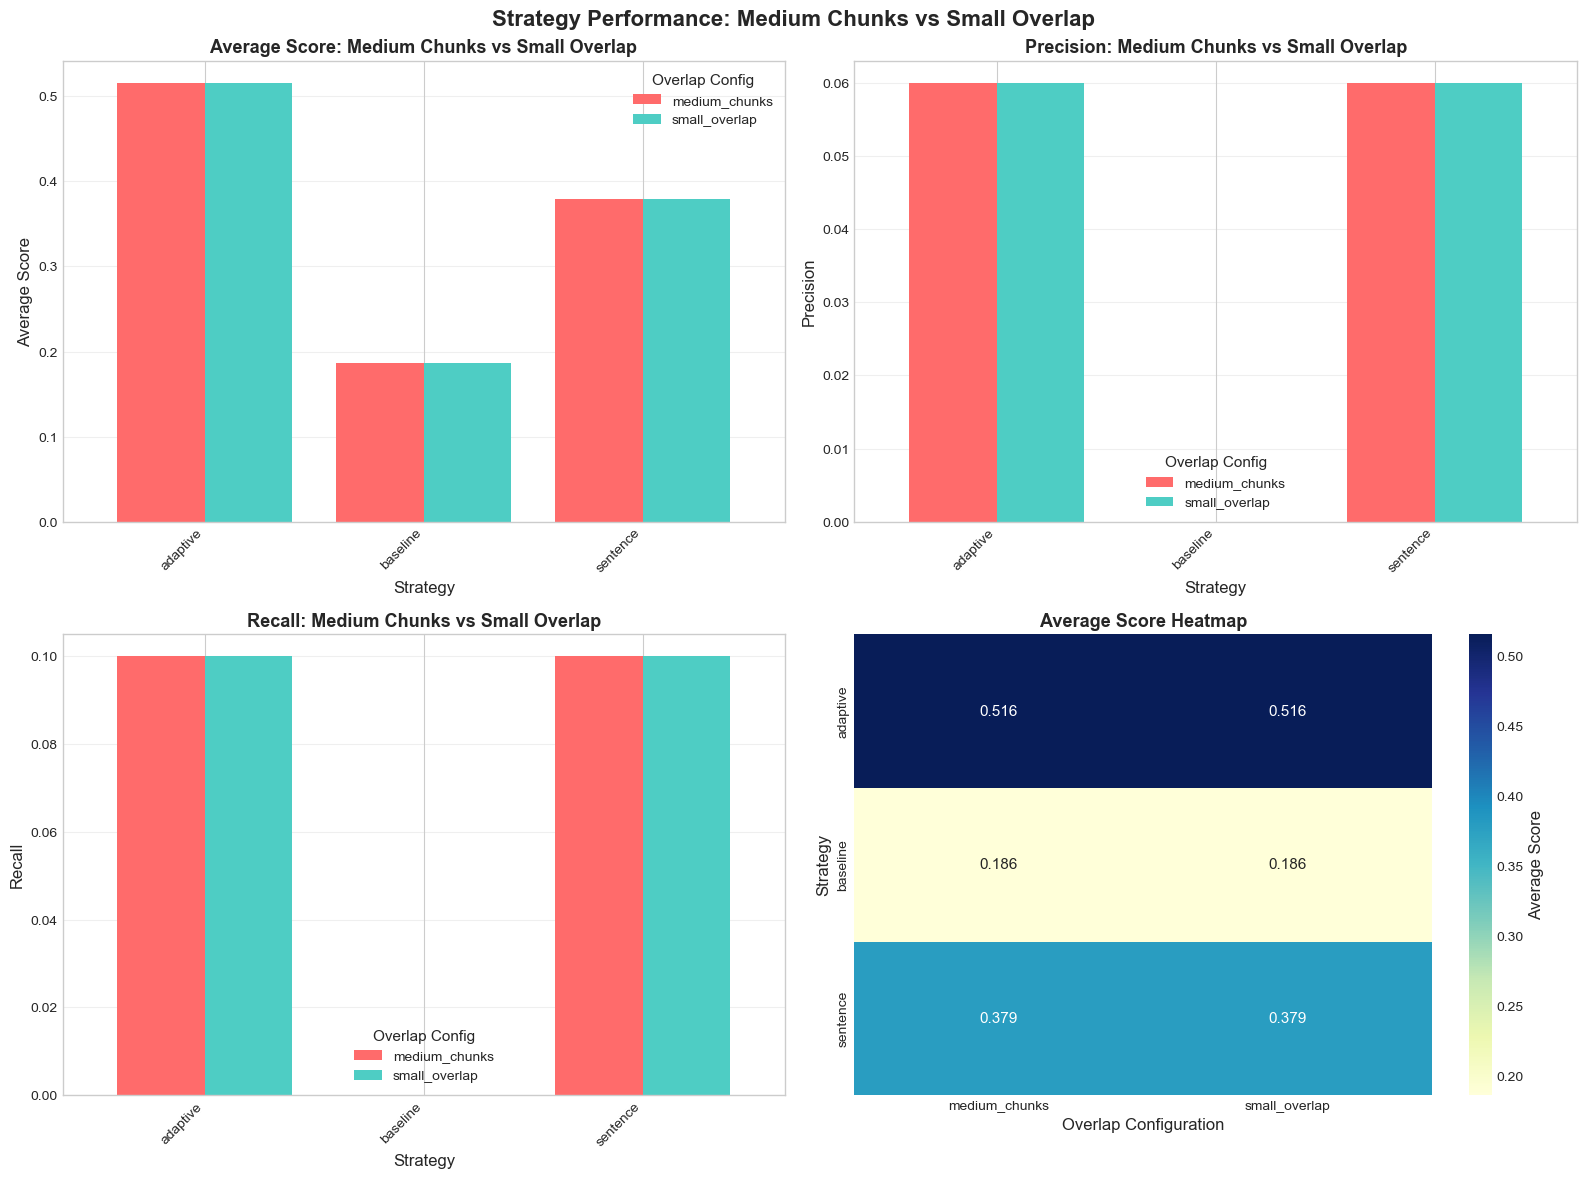

✅ Overlap comparison visualization saved!


In [38]:
# Visualization: Overlap Size Comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Strategy Performance: Medium Chunks vs Small Overlap', fontsize=16, fontweight='bold')

# Plot 1: Average Score Comparison
ax1 = axes[0, 0]
if not overlap_comparison_df.empty:
    pivot_avg = overlap_comparison_df.pivot(index='strategy', columns='overlap_config', values='avg_score_mean')
    pivot_avg.plot(kind='bar', ax=ax1, width=0.8, color=['#FF6B6B', '#4ECDC4'])
    ax1.set_xlabel('Strategy', fontsize=12)
    ax1.set_ylabel('Average Score', fontsize=12)
    ax1.set_title('Average Score: Medium Chunks vs Small Overlap', fontsize=13, fontweight='bold')
    ax1.legend(title='Overlap Config', fontsize=10)
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Plot 2: Precision Comparison
ax2 = axes[0, 1]
if not overlap_comparison_df.empty:
    pivot_prec = overlap_comparison_df.pivot(index='strategy', columns='overlap_config', values='precision_mean')
    pivot_prec.plot(kind='bar', ax=ax2, width=0.8, color=['#FF6B6B', '#4ECDC4'])
    ax2.set_xlabel('Strategy', fontsize=12)
    ax2.set_ylabel('Precision', fontsize=12)
    ax2.set_title('Precision: Medium Chunks vs Small Overlap', fontsize=13, fontweight='bold')
    ax2.legend(title='Overlap Config', fontsize=10)
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

# Plot 3: Recall Comparison
ax3 = axes[1, 0]
if not overlap_comparison_df.empty:
    pivot_rec = overlap_comparison_df.pivot(index='strategy', columns='overlap_config', values='recall_mean')
    pivot_rec.plot(kind='bar', ax=ax3, width=0.8, color=['#FF6B6B', '#4ECDC4'])
    ax3.set_xlabel('Strategy', fontsize=12)
    ax3.set_ylabel('Recall', fontsize=12)
    ax3.set_title('Recall: Medium Chunks vs Small Overlap', fontsize=13, fontweight='bold')
    ax3.legend(title='Overlap Config', fontsize=10)
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')

# Plot 4: Heatmap
ax4 = axes[1, 1]
if not overlap_comparison_df.empty:
    heatmap_data = overlap_comparison_df.pivot(index='strategy', columns='overlap_config', values='avg_score_mean')
    sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlGnBu', cbar_kws={'label': 'Average Score'}, ax=ax4)
    ax4.set_title('Average Score Heatmap', fontsize=13, fontweight='bold')
    ax4.set_xlabel('Overlap Configuration', fontsize=12)
    ax4.set_ylabel('Strategy', fontsize=12)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'overlap_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Overlap comparison visualization saved!")


## 6. Analysis 3: Strategy Comparison Across Chunking Methods (Small Chunks vs Medium Chunks)


In [39]:
# Prepare chunk size comparison data
chunk_comparison_data = []

# Small chunks
if small_chunks_results is not None:
    for strategy in small_chunks_results['strategy'].unique():
        strategy_df = small_chunks_results[small_chunks_results['strategy'] == strategy]
        chunk_comparison_data.append({
            'chunk_size': 'small',
            'strategy': strategy,
            'avg_score_mean': strategy_df['avg_score'].mean(),
            'avg_score_std': strategy_df['avg_score'].std(),
            'max_score_mean': strategy_df['max_score'].mean(),
            'precision_mean': strategy_df['precision'].mean(),
            'recall_mean': strategy_df['recall'].mean(),
            'accuracy_mean': strategy_df['accuracy'].mean(),
            'namespace_correct_rate': strategy_df['namespace_correct'].mean(),
            'num_queries': len(strategy_df)
        })

# Medium chunks
if medium_chunks_results is not None:
    for strategy in medium_chunks_results['strategy'].unique():
        strategy_df = medium_chunks_results[medium_chunks_results['strategy'] == strategy]
        chunk_comparison_data.append({
            'chunk_size': 'medium',
            'strategy': strategy,
            'avg_score_mean': strategy_df['avg_score'].mean(),
            'avg_score_std': strategy_df['avg_score'].std(),
            'max_score_mean': strategy_df['max_score'].mean(),
            'precision_mean': strategy_df['precision'].mean(),
            'recall_mean': strategy_df['recall'].mean(),
            'accuracy_mean': strategy_df['accuracy'].mean(),
            'namespace_correct_rate': strategy_df['namespace_correct'].mean(),
            'num_queries': len(strategy_df)
        })

chunk_comparison_df = pd.DataFrame(chunk_comparison_data)
print("✅ Chunk size comparison data prepared!")
print(f"\n{chunk_comparison_df}")


✅ Chunk size comparison data prepared!

  chunk_size  strategy  avg_score_mean  avg_score_std  max_score_mean  \
0      small  baseline        0.279626       0.132406        0.329635   
1      small  sentence        0.417657       0.120667        0.445577   
2      small  adaptive        0.516635       0.128450        0.544321   
3     medium  baseline        0.186470       0.113131        0.242872   
4     medium  sentence        0.379217       0.115480        0.427168   
5     medium  adaptive        0.515640       0.130678        0.542172   

   precision_mean  recall_mean  accuracy_mean  namespace_correct_rate  \
0            0.01     0.016667           0.01                     1.0   
1            0.05     0.083333           0.05                     1.0   
2            0.08     0.133333           0.08                     1.0   
3            0.00     0.000000           0.00                     0.9   
4            0.06     0.100000           0.06                     1.0   
5         

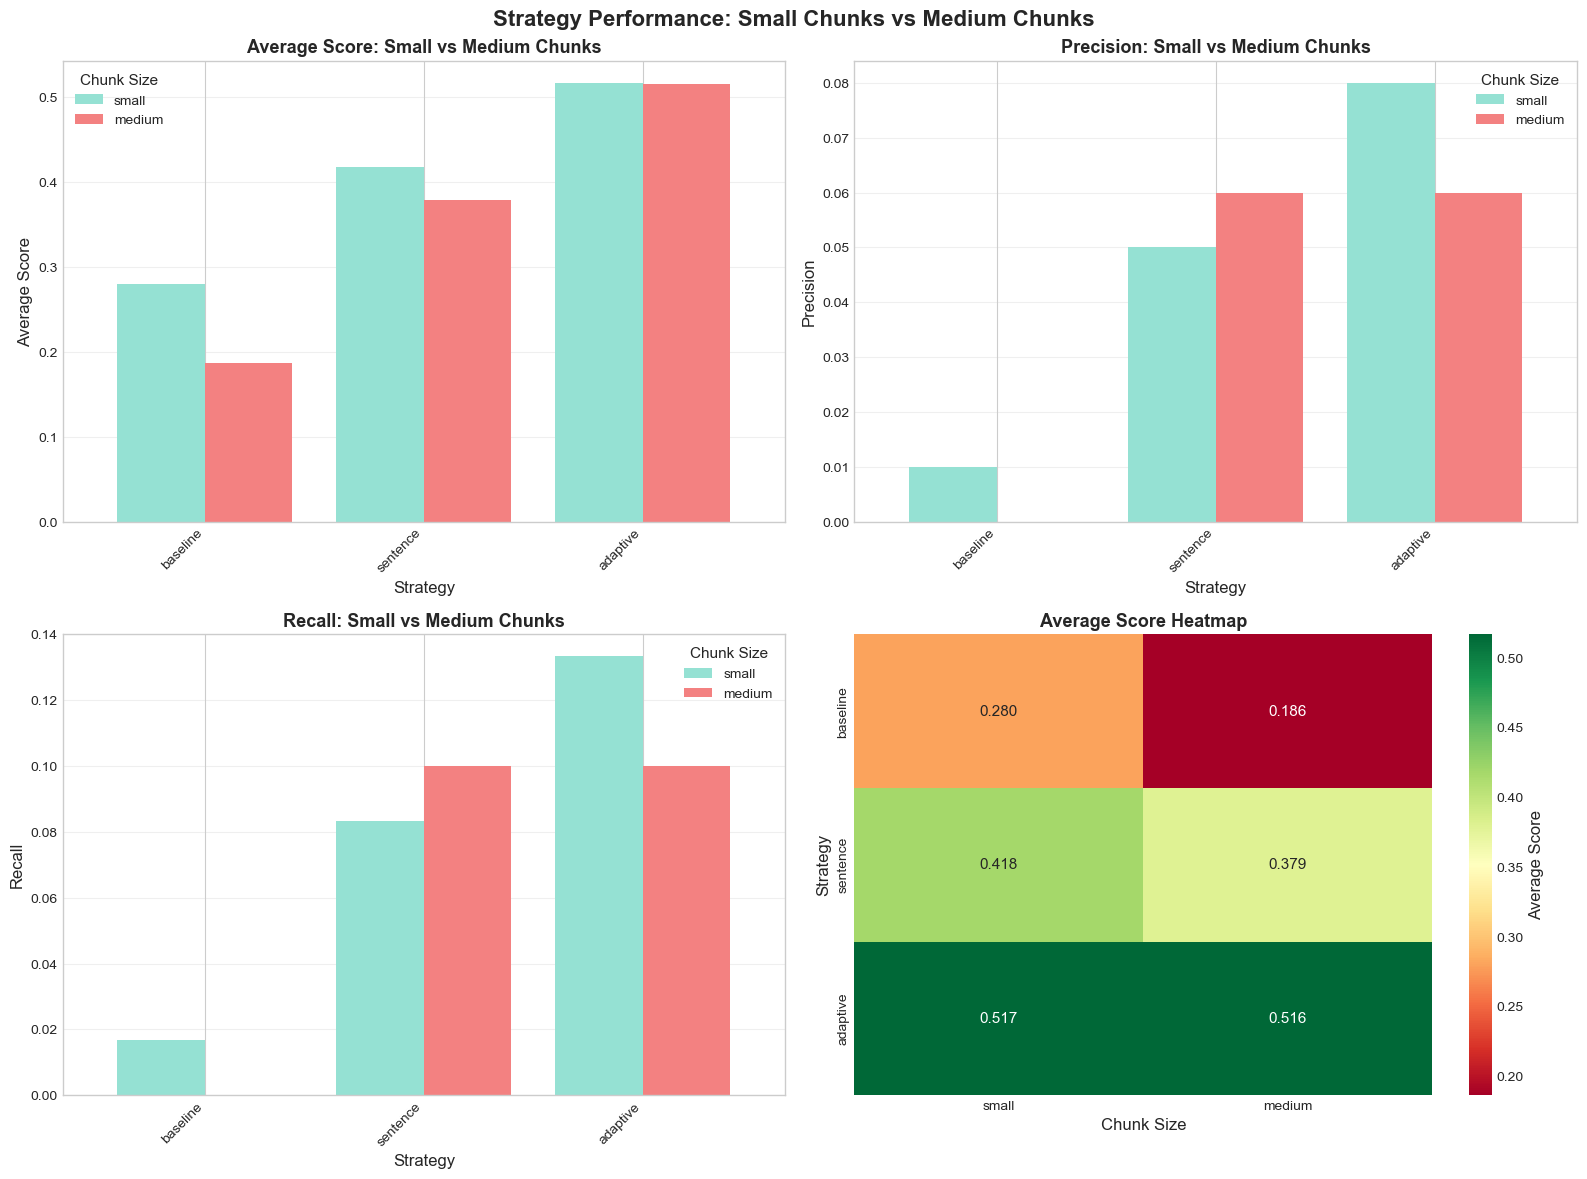

✅ Chunk size comparison visualization saved!


In [40]:
# Visualization: Chunk Size Comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Strategy Performance: Small Chunks vs Medium Chunks', fontsize=16, fontweight='bold')

# Helper function to create complete pivot table
def create_complete_pivot(df, value_col):
    """Create a pivot table ensuring all strategies and chunk sizes are present."""
    pivot = df.pivot(index='strategy', columns='chunk_size', values=value_col)
    # Get all unique strategies and chunk sizes
    all_strategies = df['strategy'].unique()
    all_chunk_sizes = ['small', 'medium']
    
    # Create a complete index with all strategies
    complete_index = pd.Index(all_strategies, name='strategy')
    pivot = pivot.reindex(complete_index)
    
    # Ensure both columns exist
    for chunk_size in all_chunk_sizes:
        if chunk_size not in pivot.columns:
            pivot[chunk_size] = 0.0
    
    # Fill NaN values with 0
    pivot = pivot.fillna(0)
    
    # Reorder columns to ensure consistent order
    pivot = pivot[['small', 'medium']]
    
    return pivot

# Plot 1: Average Score Comparison
ax1 = axes[0, 0]
if not chunk_comparison_df.empty:
    pivot_avg = create_complete_pivot(chunk_comparison_df, 'avg_score_mean')
    pivot_avg.plot(kind='bar', ax=ax1, width=0.8, color=['#95E1D3', '#F38181'])
    ax1.set_xlabel('Strategy', fontsize=12)
    ax1.set_ylabel('Average Score', fontsize=12)
    ax1.set_title('Average Score: Small vs Medium Chunks', fontsize=13, fontweight='bold')
    ax1.legend(title='Chunk Size', fontsize=10)
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Plot 2: Precision Comparison
ax2 = axes[0, 1]
if not chunk_comparison_df.empty:
    pivot_prec = create_complete_pivot(chunk_comparison_df, 'precision_mean')
    pivot_prec.plot(kind='bar', ax=ax2, width=0.8, color=['#95E1D3', '#F38181'])
    ax2.set_xlabel('Strategy', fontsize=12)
    ax2.set_ylabel('Precision', fontsize=12)
    ax2.set_title('Precision: Small vs Medium Chunks', fontsize=13, fontweight='bold')
    ax2.legend(title='Chunk Size', fontsize=10)
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
    # Set y-axis to start from 0 to ensure 0 values are visible
    ax2.set_ylim(bottom=0)

# Plot 3: Recall Comparison
ax3 = axes[1, 0]
if not chunk_comparison_df.empty:
    pivot_rec = create_complete_pivot(chunk_comparison_df, 'recall_mean')
    pivot_rec.plot(kind='bar', ax=ax3, width=0.8, color=['#95E1D3', '#F38181'])
    ax3.set_xlabel('Strategy', fontsize=12)
    ax3.set_ylabel('Recall', fontsize=12)
    ax3.set_title('Recall: Small vs Medium Chunks', fontsize=13, fontweight='bold')
    ax3.legend(title='Chunk Size', fontsize=10)
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')
    # Set y-axis to start from 0 to ensure 0 values are visible
    ax3.set_ylim(bottom=0)

# Plot 4: Heatmap
ax4 = axes[1, 1]
if not chunk_comparison_df.empty:
    heatmap_data = create_complete_pivot(chunk_comparison_df, 'avg_score_mean')
    sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', cbar_kws={'label': 'Average Score'}, ax=ax4)
    ax4.set_title('Average Score Heatmap', fontsize=13, fontweight='bold')
    ax4.set_xlabel('Chunk Size', fontsize=12)
    ax4.set_ylabel('Strategy', fontsize=12)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'chunk_size_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Chunk size comparison visualization saved!")


## 7. Comprehensive Comparison: All Factors Combined


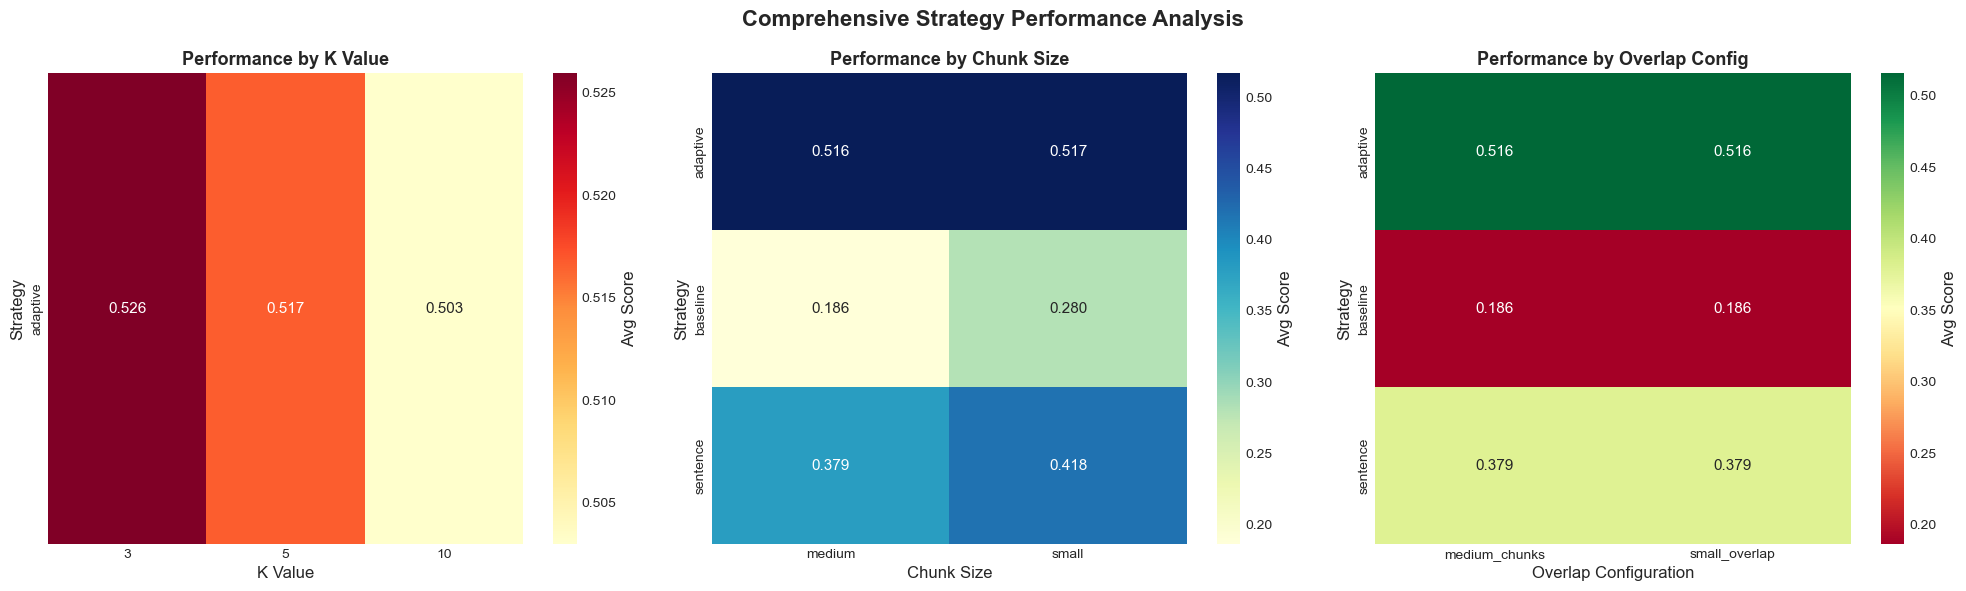

✅ Comprehensive heatmap saved!


In [41]:
# Create a comprehensive heatmap showing all combinations
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Comprehensive Strategy Performance Analysis', fontsize=16, fontweight='bold')

# Heatmap 1: By Strategy and K Value
ax1 = axes[0]
if not k_comparison_df.empty:
    heatmap_k = k_comparison_df.pivot(index='strategy', columns='k_value', values='avg_score_mean')
    sns.heatmap(heatmap_k, annot=True, fmt='.3f', cmap='YlOrRd', cbar_kws={'label': 'Avg Score'}, ax=ax1)
    ax1.set_title('Performance by K Value', fontsize=13, fontweight='bold')
    ax1.set_xlabel('K Value', fontsize=12)
    ax1.set_ylabel('Strategy', fontsize=12)

# Heatmap 2: By Strategy and Chunk Size
ax2 = axes[1]
if not chunk_comparison_df.empty:
    heatmap_chunk = chunk_comparison_df.pivot(index='strategy', columns='chunk_size', values='avg_score_mean')
    sns.heatmap(heatmap_chunk, annot=True, fmt='.3f', cmap='YlGnBu', cbar_kws={'label': 'Avg Score'}, ax=ax2)
    ax2.set_title('Performance by Chunk Size', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Chunk Size', fontsize=12)
    ax2.set_ylabel('Strategy', fontsize=12)

# Heatmap 3: By Strategy and Overlap Config
ax3 = axes[2]
if not overlap_comparison_df.empty:
    heatmap_overlap = overlap_comparison_df.pivot(index='strategy', columns='overlap_config', values='avg_score_mean')
    sns.heatmap(heatmap_overlap, annot=True, fmt='.3f', cmap='RdYlGn', cbar_kws={'label': 'Avg Score'}, ax=ax3)
    ax3.set_title('Performance by Overlap Config', fontsize=13, fontweight='bold')
    ax3.set_xlabel('Overlap Configuration', fontsize=12)
    ax3.set_ylabel('Strategy', fontsize=12)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'comprehensive_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Comprehensive heatmap saved!")


## 8. Best Configuration Analysis


In [42]:
# Find best configurations
best_configs = []

# Best by K value
if not k_comparison_df.empty:
    best_k = k_comparison_df.loc[k_comparison_df['avg_score_mean'].idxmax()]
    best_configs.append({
        'dimension': 'K Value',
        'best_strategy': best_k['strategy'],
        'best_k': best_k['k_value'],
        'avg_score': best_k['avg_score_mean'],
        'precision': best_k['precision_mean'],
        'recall': best_k['recall_mean']
    })

# Best by chunk size
if not chunk_comparison_df.empty:
    best_chunk = chunk_comparison_df.loc[chunk_comparison_df['avg_score_mean'].idxmax()]
    best_configs.append({
        'dimension': 'Chunk Size',
        'best_strategy': best_chunk['strategy'],
        'best_chunk_size': best_chunk['chunk_size'],
        'avg_score': best_chunk['avg_score_mean'],
        'precision': best_chunk['precision_mean'],
        'recall': best_chunk['recall_mean']
    })

# Best by overlap
if not overlap_comparison_df.empty:
    best_overlap = overlap_comparison_df.loc[overlap_comparison_df['avg_score_mean'].idxmax()]
    best_configs.append({
        'dimension': 'Overlap Size',
        'best_strategy': best_overlap['strategy'],
        'best_overlap': best_overlap['overlap_config'],
        'avg_score': best_overlap['avg_score_mean'],
        'precision': best_overlap['precision_mean'],
        'recall': best_overlap['recall_mean']
    })

best_configs_df = pd.DataFrame(best_configs)
print("✅ Best configurations identified!")
print(f"\n{best_configs_df.to_string()}")

# Print best configuration in a readable format
print("\n" + "="*80)
print("BEST CONFIGURATION SUMMARY")
print("="*80)

if not best_configs_df.empty:
    # Find overall best configuration (highest avg_score)
    overall_best = best_configs_df.loc[best_configs_df['avg_score'].idxmax()]
    print(f"\n🏆 OVERALL BEST CONFIGURATION:")
    print(f"   Strategy: {overall_best['best_strategy']}")
    print(f"   Average Score: {overall_best['avg_score']:.4f}")
    print(f"   Precision: {overall_best['precision']:.4f}")
    print(f"   Recall: {overall_best['recall']:.4f}")
    
    # Print best for each dimension
    print(f"\n📊 BEST CONFIGURATION BY DIMENSION:")
    for idx, row in best_configs_df.iterrows():
        print(f"\n   {row['dimension']}:")
        print(f"      Strategy: {row['best_strategy']}")
        if pd.notna(row.get('best_k')):
            print(f"      K Value: {int(row['best_k'])}")
        if pd.notna(row.get('best_chunk_size')):
            print(f"      Chunk Size: {row['best_chunk_size']}")
        if pd.notna(row.get('best_overlap')):
            print(f"      Overlap Config: {row['best_overlap']}")
        print(f"      Average Score: {row['avg_score']:.4f}")
        print(f"      Precision: {row['precision']:.4f}")
        print(f"      Recall: {row['recall']:.4f}")

print("\n" + "="*80)

# Save to CSV
best_configs_df.to_csv(RESULTS_DIR / 'best_configurations.csv', index=False)
print(f"\n✅ Best configurations saved to CSV!")


✅ Best configurations identified!

      dimension best_strategy  best_k  avg_score  precision    recall best_chunk_size   best_overlap
0       K Value      adaptive     3.0   0.525941       0.10  0.100000             NaN            NaN
1    Chunk Size      adaptive     NaN   0.516635       0.08  0.133333           small            NaN
2  Overlap Size      adaptive     NaN   0.515640       0.06  0.100000             NaN  medium_chunks

BEST CONFIGURATION SUMMARY

🏆 OVERALL BEST CONFIGURATION:
   Strategy: adaptive
   Average Score: 0.5259
   Precision: 0.1000
   Recall: 0.1000

📊 BEST CONFIGURATION BY DIMENSION:

   K Value:
      Strategy: adaptive
      K Value: 3
      Average Score: 0.5259
      Precision: 0.1000
      Recall: 0.1000

   Chunk Size:
      Strategy: adaptive
      Chunk Size: small
      Average Score: 0.5166
      Precision: 0.0800
      Recall: 0.1333

   Overlap Size:
      Strategy: adaptive
      Overlap Config: medium_chunks
      Average Score: 0.5156
      P

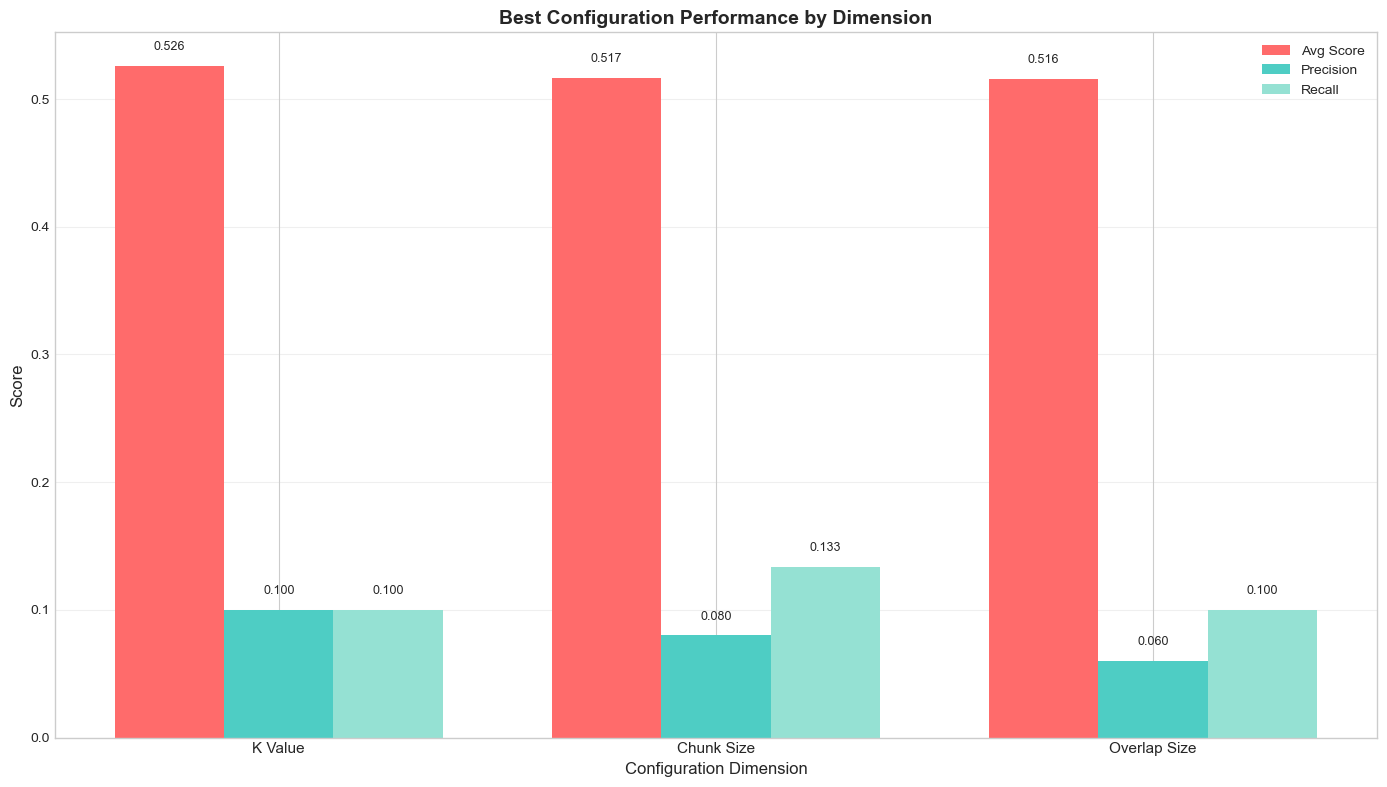

✅ Best configurations visualization saved!


In [43]:
# Create a summary visualization of best configurations
fig, ax = plt.subplots(figsize=(14, 8))

if not best_configs_df.empty:
    x_pos = np.arange(len(best_configs_df))
    width = 0.25
    
    ax.bar(x_pos - width, best_configs_df['avg_score'], width, label='Avg Score', color='#FF6B6B')
    ax.bar(x_pos, best_configs_df['precision'], width, label='Precision', color='#4ECDC4')
    ax.bar(x_pos + width, best_configs_df['recall'], width, label='Recall', color='#95E1D3')
    
    ax.set_xlabel('Configuration Dimension', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Best Configuration Performance by Dimension', fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(best_configs_df['dimension'], fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, (idx, row) in enumerate(best_configs_df.iterrows()):
        ax.text(i - width, row['avg_score'] + 0.01, f"{row['avg_score']:.3f}", 
                ha='center', va='bottom', fontsize=9)
        ax.text(i, row['precision'] + 0.01, f"{row['precision']:.3f}", 
                ha='center', va='bottom', fontsize=9)
        ax.text(i + width, row['recall'] + 0.01, f"{row['recall']:.3f}", 
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'best_configurations.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Best configurations visualization saved!")
